# REINFORCE: Policy Gradients and Variance Reduction
> - Full Name: **Radin Cheraghi**


## Objective

In this notebook, you will implement the **REINFORCE policy gradient algorithm** (also known as Monte Carlo policy gradient) to train an agent on the **CartPole‑v1** environment from OpenAI Gym. REINFORCE is a fundamental policy‑based reinforcement learning method that directly optimises the policy parameters by performing stochastic gradient ascent on the expected cumulative reward. However, the standard REINFORCE update is known to suffer from **high variance**, which can lead to slow convergence and unstable learning curves.

## Variance Reduction Techniques

To address this issue, this notebook further explores three variance‑reduction strategies that are commonly applied to the REINFORCE algorithm. You will implement each of them and empirically analyse their effects on learning speed, stability, and final performance. The techniques are:

1. **The causality trick (reward‑to‑go)**  
   Instead of using the full return from the start of an episode, this method replaces the cumulative reward with the sum of future rewards from each time step onward. By ignoring rewards obtained before the current action, the gradient estimator retains the same unbiasedness while significantly reducing variance.

2. **Constant baseline**  
   A fixed scalar baseline is subtracted from the return (or the reward‑to‑go) in the policy gradient estimate. Subtracting a constant does not introduce bias, but a well‑chosen constant (e.g., the average return over recent episodes) can reduce variance by centring the advantage estimates.

3. **Learned baseline (value function baseline)**  
   A more sophisticated approach that uses a separate function approximator (typically a neural network) to estimate the state‑value function. This learned baseline adapts during training and provides a state‑dependent offset. The advantage estimate then often yields the lowest variance among these three methods, at the cost of adding a second learning process.

## Implementation and Analysis

You will implement the core REINFORCE update, then systematically extend it with each of the three variance‑reduction techniques. For every variant, you will run multiple training episodes, plot the smoothed episode returns, and compare convergence behaviour. The notebook will guide you through:

- Setting up the CartPole‑v1 environment (discrete action space, continuous observation space).
- Defining a policy network (e.g., a shallow multi‑layer perceptron) with a softmax output layer.
- Writing the training loop that collects episodes, computes policy gradients, and updates the policy.
- Modifying the advantage estimator to incorporate causality and baseline subtractions.
- Training and evaluating each variant with identical random seeds for fair comparison.

By the end of this notebook, you will gain hands‑on insight into how different variance‑reduction mechanisms affect the practical performance of Monte Carlo policy gradient methods.


# Setup


All required packages are pre-installed if using Google Colab.


Import the following libraries.


In [10]:
import sys
print(sys.executable)

c:\Users\ideapad 5\AppData\Local\Programs\Python\Python311\python.exe


In [11]:
import sys
!"{sys.executable}" -m pip install gym

Looking in indexes: https://mirror-pypi.runflare.com/simple


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
     -------------------------------------- 721.7/721.7 kB 4.9 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827740 sha256=1a9525e60f425fa47b0ca2070d7123983c0bcd903f99de53c1f270268045b346
  Stored in directory: c:\users\ideapad 5\appdata\local\pip\cache\wheels\3f\21\1c\c385046c59750577df46e0896dbc27f7fa9fe90c41b0f655e4
Successfully built gym


In [38]:
!"{sys.executable}" -m pip install "imageio[ffmpeg]"

Looking in indexes: https://mirror-pypi.runflare.com/simple
   ---------------------------------------- 0.0/31.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/31.2 MB 5.0 MB/s eta 0:00:06
   --- ------------------------------------ 2.9/31.2 MB 6.7 MB/s eta 0:00:05
   ----- ---------------------------------- 4.5/31.2 MB 7.1 MB/s eta 0:00:04
   ------- -------------------------------- 6.0/31.2 MB 7.2 MB/s eta 0:00:04
   --------- ------------------------------ 7.6/31.2 MB 7.2 MB/s eta 0:00:04
   ----------- ---------------------------- 9.2/31.2 MB 7.3 MB/s eta 0:00:04
   ------------- -------------------------- 10.5/31.2 MB 7.3 MB/s eta 0:00:03
   --------------- ------------------------ 12.1/31.2 MB 7.1 MB/s eta 0:00:03
   ----------------- ---------------------- 13.9/31.2 MB 7.3 MB/s eta 0:00:03
   -------------------- ------------------- 15.7/31.2 MB 7.4 MB/s eta 0:00:03
   ---------------------- ----------------- 17.6/31.2 MB 7.5 MB/s eta 0:00:02
   ---------------


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# Imports
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import gym
import matplotlib
import matplotlib.pyplot as plt
import base64
import imageio.v2 as imageio
import IPython
import logging
import warnings

# Disable warnings
logging.getLogger().setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# DEVICE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

C:\Users\ideapad 5\AppData\Local\Temp\ipykernel_12972\121051384.py:3: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not hasattr(np, 'bool8'):
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


device(type='cpu')

Note: While we check for CUDA availability, using a GPU is not strictly necessary for this project. The neural networks used here are small, and the majority of training time is spent running episodes in the environment (which occurs on the CPU), rather than performing backpropagation updates.


Set a fix seed to be able to compare results


In [2]:
def set_seed(seed=333, env=None):
    import random

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    if env is not None:
        env.reset(seed=seed)
        env.action_space.seed(seed)
        env.observation_space.seed(seed)

Configure Matplotlib for Interactive and XKCD-Style Plots


In [3]:
# Set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display
plt.ion()
plt.xkcd(scale=1, length=100, randomness=2)
matplotlib.rcParams['figure.figsize'] = (12, 6)

Record and Embed Simulation Videos in Jupyter Notebook


<b>embed_mp4:</b> Converts an MP4 video into a base64-encoded HTML tag for display in Jupyter Notebook.
<br>
<b>record_simulation:</b> Runs a policy in the environment, records the simulation, and saves it as an MP4 video.


In [4]:
def embed_mp4(filename):
    video = open(filename,'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())
    return IPython.display.HTML(tag)

# def record_simulation(env, policy_net, filename, episodes=1, fps=30):
#     filename = "media/" + filename + ".mp4"
#     with imageio.get_writer(filename, fps=fps) as video:
#         for _ in range(episodes):
#             state = env.reset()
#             frame = env.render()  # Capture the first frame
#             video.append_data(frame[0])

#             done = False
#             while not done:
#                 state_tensor = torch.FloatTensor(state).to(DEVICE)
#                 action = torch.argmax(policy_net(state_tensor)).item()
#                 state, _, terminated, truncated, _ = env.step(action)

#                 frame = env.render()  # Capture the frame after taking the action
#                 video.append_data(frame[0])

#                 done = terminated or truncated
#     return embed_mp4(filename)

def record_simulation(env, policy_net, filename, episodes=1, fps=30):
    filename = "media/" + filename + ".mp4"

    with imageio.get_writer(filename, fps=fps) as video:
        for _ in range(episodes):
            reset_out = env.reset()
            state = reset_out[0] if isinstance(reset_out, tuple) else reset_out

            frame = env.render()
            video.append_data(frame)

            done = False
            while not done:
                state_tensor = torch.FloatTensor(state).to(DEVICE)

                with torch.no_grad():
                    action = torch.argmax(policy_net(state_tensor)).item()

                step_out = env.step(action)

                if len(step_out) == 5:
                    state, _, terminated, truncated, _ = step_out
                    done = terminated or truncated
                else:
                    state, _, done, _ = step_out

                frame = env.render()
                video.append_data(frame)

    return embed_mp4(filename)

# Explore the environment


Initialize CartPole Environment and Display State & Action Spaces


In [5]:
# Create the CartPole environment
env = gym.make("CartPole-v1")
set_seed(333, env)

# Print observation and action space
print("Observation Space:", env.observation_space)
print("Action Space:", env.action_space)

Observation Space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
Action Space: Discrete(2)


**Question**

How are the observation and action spaces defined in the CartPole environment?

**Answer:**

In CartPole-v1, the observation space is a continuous 4-dimensional Box containing the cart position, cart velocity, pole angle, and pole angular velocity. The action space is Discrete(2), where action 0 pushes the cart to the left and action 1 pushes it to the right.


Define a Random Policy for Action Selection  


In [6]:
class RandomPolicy(object):

    def __init__(self, action_space_n):
        self.action_space_n = action_space_n

    def __call__(self, state):
        action_values = torch.rand(self.action_space_n)
        return action_values

Visualize the random policy.


In [7]:
import numpy as np

random_policy = RandomPolicy(env.action_space.n)

record_simulation(
    gym.make("CartPole-v1", render_mode='rgb_array'),
    random_policy,
    "Video_CartPole_random_policy"
)

# Agent with REINFORCE: Normal vs Causality vs Simple Baseline vs Learned Baseline


### Policy Network Definition


To define a neural network that represents the agent’s policy for selecting actions.

The policy network takes the environment’s state as input and outputs a probability distribution over possible actions.


In [8]:
# Helper functions for Gym API compatibility
def reset_env(env):
    reset_out = env.reset()
    if isinstance(reset_out, tuple):
        state, _ = reset_out
    else:
        state = reset_out
    return state


def step_env(env, action):
    step_out = env.step(action)

    if len(step_out) == 5:
        next_state, reward, terminated, truncated, info = step_out
        done = terminated or truncated
    else:
        next_state, reward, done, info = step_out

    return next_state, reward, done, info

In [9]:
# TODO: Define the Policy Network
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PolicyNetwork, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim),
            nn.Softmax(dim=-1)
        )

    def forward(self, state):
        return self.net(state)

### REINFORCE without Causality

#### 1. The Objective Function
In Policy Gradient methods, we aim to maximize the expected return:
$$J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} [G(\tau)]$$
where $\tau = (s_0, a_0, s_1, a_1, \dots, s_T)$ is a trajectory sampled from the policy $\pi_\theta$, and $G(\tau)$ is the total discounted return.

#### 2. The Policy Gradient Theorem
The gradient of the objective function is given by:
$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \left( \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) \right) G(\tau) \right]$$

#### 3. Full Return vs. Reward-to-go
In the code implementation `reinforce_no_causality`, we use the **Full Return** $G_0$ for every action in the trajectory:
- **Definition of $G_0$**: $G_0 = \sum_{k=0}^{T} \gamma^k R_k$
- **Update Rule**: $\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t | s_t) G_0$

#### Definitions:
- **$\pi_\theta(a_t | s_t)$**: The probability of taking action $a_t$ given state $s_t$ under parameters $\theta$.
- **$\nabla_\theta \log \pi_\theta(a_t | s_t)$**: The 'score function' or direction in parameter space that increases the probability of action $a_t$.
- **$G_0$**: The total scalar reward of the entire episode. If the episode was good, $G_0$ is high, and we push the probabilities of *all* actions taken in that episode 'up' equally.


In [10]:
# TODO: Implement REINFORCE without causality (using Full Return G_0)
def reinforce_no_causality(env, policy_net, optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []

    for episode in range(num_episodes):
        log_probs = []
        rewards = []

        state = reset_env(env)
        done = False

        # 1. Collect trajectory
        while not done:
            state_tensor = torch.FloatTensor(state).to(DEVICE)

            action_probs = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action = dist.sample()

            log_probs.append(dist.log_prob(action))

            state, reward, done, _ = step_env(env, action.item())
            rewards.append(reward)

        episode_reward = sum(rewards)
        rewards_per_episode.append(episode_reward)

        if (episode + 1) % 50 == 0:
            print(f"[No Causality Trick] Episode {episode + 1}, Reward: {episode_reward:.1f}")

        # 2. Compute G_0: full discounted episode return
        G_0 = 0
        for t, reward in enumerate(rewards):
            G_0 += (gamma ** t) * reward

        G_0 = torch.tensor(G_0, dtype=torch.float32).to(DEVICE)

        # 3. Update policy
        log_probs = torch.stack(log_probs)
        policy_loss = -(log_probs * G_0).sum()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

    return rewards_per_episode

**Question:**

Why does this method has high variance?



**Answer:**
This method has high variance because every action in the episode is updated using the same full return $G_0$, even if some actions had little or no causal effect on later rewards. As a result, early and late actions are all credited or blamed equally, making the gradient estimate noisy.


### REINFORCE with Causality


To implement a function that calculates the discounted return for each timestep in an episode.

$$[
G_t = \sum_{k=0}^{T-t} \gamma^k R_{t+k}
]$$


In [11]:
# TODO: Implement the function to compute discounted returns (Reward-to-go)
def compute_returns(rewards, gamma=0.99):
    returns = []
    G = 0

    for reward in reversed(rewards):
        G = reward + gamma * G
        returns.insert(0, G)

    return torch.tensor(returns, dtype=torch.float32).to(DEVICE)

To train the agent using the standard policy gradient method.
The REINFORCE algorithm updates policy parameters by using the log-probability of actions multiplied by the discounted return.

This algorithm optimizes a **stochastic policy** $( \pi_{\theta}(a_t \mid s_t) )$ by updating its parameters in the direction that increases expected rewards. The update rule is based on the **policy gradient theorem**:  

$$[
\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_{\theta} \log \pi_{\theta}(a_t \mid s_t) G_t
]$$

where:  

- $( \theta )$ are the policy parameters (weights of the neural network).  
- $( \alpha )$ is the learning rate.  
- $( G_t )$ is the **discounted return** from timestep $( t )$:  

- $( \nabla_{\theta} \log \pi_{\theta}(a_t \mid s_t) )$ is the gradient of the log-probability of the selected action, used to adjust the policy in the correct direction.


In [12]:
# TODO: Implement the REINFORCE algorithm (with Causality, No Baseline)
def reinforce(env, policy_net, optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []

    for episode in range(num_episodes):
        log_probs = []
        rewards = []

        state = reset_env(env)
        done = False

        while not done:
            state_tensor = torch.FloatTensor(state).to(DEVICE)

            action_probs = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action = dist.sample()

            log_probs.append(dist.log_prob(action))

            state, reward, done, _ = step_env(env, action.item())
            rewards.append(reward)

        episode_reward = sum(rewards)
        rewards_per_episode.append(episode_reward)

        if (episode + 1) % 50 == 0:
            print(f"[No Baseline] Episode {episode + 1}, Reward: {episode_reward:.1f}")

        returns = compute_returns(rewards, gamma)
        log_probs = torch.stack(log_probs)

        policy_loss = -(log_probs * returns).sum()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

    return rewards_per_episode

### REINFORCE with a Constant Baseline

A simple way to reduce variance is to subtract a constant baseline from the returns. A common choice for this constant is the average return of the episode:

$$\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_{\theta} \log \pi_{\theta}(a_t | s_t) (G_t - b)$$

where $b = \frac{1}{T} \sum_{t=0}^T G_t$.


In [13]:
# TODO: Implement REINFORCE with a Constant Baseline
def reinforce_constant_baseline(env, policy_net, optimizer, num_episodes=1000, gamma=0.99):
    rewards_per_episode = []

    for episode in range(num_episodes):
        log_probs = []
        rewards = []

        state = reset_env(env)
        done = False

        while not done:
            state_tensor = torch.FloatTensor(state).to(DEVICE)

            action_probs = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action = dist.sample()

            log_probs.append(dist.log_prob(action))

            state, reward, done, _ = step_env(env, action.item())
            rewards.append(reward)

        episode_reward = sum(rewards)
        rewards_per_episode.append(episode_reward)

        if (episode + 1) % 50 == 0:
            print(f"[Constant Baseline] Episode {episode + 1}, Reward: {episode_reward:.1f}")

        returns = compute_returns(rewards, gamma)

        # Constant baseline: mean return within this episode
        baseline = returns.mean()
        advantages = returns - baseline

        log_probs = torch.stack(log_probs)
        policy_loss = -(log_probs * advantages).sum()

        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

    return rewards_per_episode

### Value Network Definition (Baseline Network)


Defines a neural network that approximates the value function, which estimates the expected return from a given state. The network takes the environment’s state as input and outputs a scalar value, representing the long-term reward the agent can expect from that state.


In [14]:
# TODO: Define the Value Network (Baseline)
class ValueNetwork(nn.Module):
    def __init__(self, input_dim):
        super(ValueNetwork, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, state):
        return self.net(state).squeeze(-1)

### Implementing REINFORCE with a Learned Baseline


To reduce variance in policy updates, we introduce a **baseline** function $( V(s) )$, which estimates the expected return from a given state. Instead of using the full return $( G_t )$, we adjust the policy update by incorporating the baseline:  

$$[
\theta \leftarrow \theta + \alpha \sum_{t=0}^{T} \nabla_{\theta} \log \pi_{\theta}(a_t \mid s_t) (G_t - V(s_t))
]$$

where:  

- $( \theta )$ are the policy parameters (weights of the neural network).  
- $( \alpha )$ is the learning rate.  
- $( G_t )$ is the **discounted return** from timestep $( t )$:  

  $$[
  G_t = \sum_{k=0}^{T-t} \gamma^k R_{t+k}
  ]$$

- $( V(s_t) )$ is the **baseline function**, estimated by a **value network**, which is trained using mean squared error (MSE) between predicted values and actual returns:  

  $$[
  L = \frac{1}{N} \sum_{t=0}^{N} (G_t - V(s_t))^2
  ]$$

The introduction of the baseline does not change the expected value of the gradient but significantly **reduces variance**, leading to more stable learning.  


In [15]:
# TODO: Implement REINFORCE with a Learned Baseline
def reinforce_with_baseline(
    env,
    policy_net,
    baseline_net,
    policy_optimizer,
    baseline_optimizer,
    num_episodes=1000,
    gamma=0.99
):
    rewards_per_episode = []

    for episode in range(num_episodes):
        states = []
        log_probs = []
        rewards = []

        state = reset_env(env)
        done = False

        while not done:
            states.append(state)

            state_tensor = torch.FloatTensor(state).to(DEVICE)

            action_probs = policy_net(state_tensor)
            dist = Categorical(action_probs)
            action = dist.sample()

            log_probs.append(dist.log_prob(action))

            state, reward, done, _ = step_env(env, action.item())
            rewards.append(reward)

        episode_reward = sum(rewards)
        rewards_per_episode.append(episode_reward)

        if (episode + 1) % 50 == 0:
            print(f"[With Baseline] Episode {episode + 1}, Reward: {episode_reward:.1f}")

        states_tensor = torch.FloatTensor(np.array(states)).to(DEVICE)
        returns = compute_returns(rewards, gamma)
        log_probs = torch.stack(log_probs)

        # Baseline prediction V(s_t)
        values = baseline_net(states_tensor)

        # Advantage estimate: G_t - V(s_t)
        advantages = returns - values.detach()

        # Policy loss
        policy_loss = -(log_probs * advantages).sum()

        policy_optimizer.zero_grad()
        policy_loss.backward()
        policy_optimizer.step()

        # Value-function loss
        value_loss = nn.MSELoss()(values, returns)

        baseline_optimizer.zero_grad()
        value_loss.backward()
        baseline_optimizer.step()

    return rewards_per_episode

### Training


To define key hyperparameters that influence training efficiency and convergence.

Hyperparameters like learning rate, discount factor, and number of episodes significantly impact the training process. Proper tuning is necessary to ensure stable learning while avoiding slow convergence or premature convergence to suboptimal policies.


In [20]:
# TODO: Define all necessary hyperparameters
INPUT_DIM = env.observation_space.shape[0]
OUTPUT_DIM = env.action_space.n

LEARNING_RATE = 1e-3
DISCOUNT_FACTOR = 0.99
NUM_EPISODES = 2000

In [21]:
# 1. Training REINFORCE without Causality (Full Return)
print("--- Training REINFORCE: No Causality (Full Return) ---")
# Use a fresh policy network
policy_net_no_causality = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
optimizer_no_causality = optim.Adam(policy_net_no_causality.parameters(), lr=LEARNING_RATE)

rewards_no_causality = reinforce_no_causality(
    env, policy_net_no_causality, optimizer_no_causality,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)

--- Training REINFORCE: No Causality (Full Return) ---
[No Causality Trick] Episode 50, Reward: 15.0
[No Causality Trick] Episode 100, Reward: 40.0
[No Causality Trick] Episode 150, Reward: 17.0
[No Causality Trick] Episode 200, Reward: 28.0
[No Causality Trick] Episode 250, Reward: 27.0
[No Causality Trick] Episode 300, Reward: 18.0
[No Causality Trick] Episode 350, Reward: 31.0
[No Causality Trick] Episode 400, Reward: 36.0
[No Causality Trick] Episode 450, Reward: 56.0
[No Causality Trick] Episode 500, Reward: 101.0
[No Causality Trick] Episode 550, Reward: 58.0
[No Causality Trick] Episode 600, Reward: 42.0
[No Causality Trick] Episode 650, Reward: 21.0
[No Causality Trick] Episode 700, Reward: 47.0
[No Causality Trick] Episode 750, Reward: 43.0
[No Causality Trick] Episode 800, Reward: 57.0
[No Causality Trick] Episode 850, Reward: 91.0
[No Causality Trick] Episode 900, Reward: 88.0
[No Causality Trick] Episode 950, Reward: 73.0
[No Causality Trick] Episode 1000, Reward: 74.0
[No 

In [22]:
# 2. Training REINFORCE with Causality (No Baseline)
print("--- Training REINFORCE: With Causality (No Baseline) ---")
policy_net_causality = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
optimizer_causality = optim.Adam(policy_net_causality.parameters(), lr=LEARNING_RATE)

rewards_no_baseline = reinforce(
    env, policy_net_causality, optimizer_causality,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)

--- Training REINFORCE: With Causality (No Baseline) ---
[No Baseline] Episode 50, Reward: 31.0
[No Baseline] Episode 100, Reward: 25.0
[No Baseline] Episode 150, Reward: 63.0
[No Baseline] Episode 200, Reward: 64.0
[No Baseline] Episode 250, Reward: 153.0
[No Baseline] Episode 300, Reward: 117.0
[No Baseline] Episode 350, Reward: 216.0
[No Baseline] Episode 400, Reward: 329.0
[No Baseline] Episode 450, Reward: 291.0
[No Baseline] Episode 500, Reward: 261.0
[No Baseline] Episode 550, Reward: 500.0
[No Baseline] Episode 600, Reward: 229.0
[No Baseline] Episode 650, Reward: 500.0
[No Baseline] Episode 700, Reward: 324.0
[No Baseline] Episode 750, Reward: 347.0
[No Baseline] Episode 800, Reward: 500.0
[No Baseline] Episode 850, Reward: 397.0
[No Baseline] Episode 900, Reward: 500.0
[No Baseline] Episode 950, Reward: 500.0
[No Baseline] Episode 1000, Reward: 500.0
[No Baseline] Episode 1050, Reward: 406.0
[No Baseline] Episode 1100, Reward: 269.0
[No Baseline] Episode 1150, Reward: 500.0
[

In [23]:
# 3. Training REINFORCE with Constant Baseline
print("--- Training REINFORCE: Constant Baseline ---")
policy_net_const_baseline = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
optimizer_const_baseline = optim.Adam(policy_net_const_baseline.parameters(), lr=LEARNING_RATE)

rewards_constant_baseline = reinforce_constant_baseline(
    env, policy_net_const_baseline, optimizer_const_baseline,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)

--- Training REINFORCE: Constant Baseline ---
[Constant Baseline] Episode 50, Reward: 13.0
[Constant Baseline] Episode 100, Reward: 118.0
[Constant Baseline] Episode 150, Reward: 119.0
[Constant Baseline] Episode 200, Reward: 22.0
[Constant Baseline] Episode 250, Reward: 195.0
[Constant Baseline] Episode 300, Reward: 153.0
[Constant Baseline] Episode 350, Reward: 128.0
[Constant Baseline] Episode 400, Reward: 385.0
[Constant Baseline] Episode 450, Reward: 375.0
[Constant Baseline] Episode 500, Reward: 173.0
[Constant Baseline] Episode 550, Reward: 311.0
[Constant Baseline] Episode 600, Reward: 247.0
[Constant Baseline] Episode 650, Reward: 500.0
[Constant Baseline] Episode 700, Reward: 413.0
[Constant Baseline] Episode 750, Reward: 229.0
[Constant Baseline] Episode 800, Reward: 488.0
[Constant Baseline] Episode 850, Reward: 500.0
[Constant Baseline] Episode 900, Reward: 500.0
[Constant Baseline] Episode 950, Reward: 500.0
[Constant Baseline] Episode 1000, Reward: 500.0
[Constant Baseli

In [24]:
# 4. Training REINFORCE with Learned Baseline
print("--- Training REINFORCE: Learned Baseline ---")
policy_net_learned_baseline = PolicyNetwork(INPUT_DIM, OUTPUT_DIM).to(DEVICE)
value_net_baseline = ValueNetwork(INPUT_DIM).to(DEVICE)

policy_opt_learned = optim.Adam(policy_net_learned_baseline.parameters(), lr=LEARNING_RATE)
value_opt_learned = optim.Adam(value_net_baseline.parameters(), lr=LEARNING_RATE)

rewards_with_baseline = reinforce_with_baseline(
    env, policy_net_learned_baseline, value_net_baseline,
    policy_opt_learned, value_opt_learned,
    num_episodes=NUM_EPISODES, gamma=DISCOUNT_FACTOR
)

--- Training REINFORCE: Learned Baseline ---
[With Baseline] Episode 50, Reward: 37.0
[With Baseline] Episode 100, Reward: 23.0
[With Baseline] Episode 150, Reward: 32.0
[With Baseline] Episode 200, Reward: 42.0
[With Baseline] Episode 250, Reward: 245.0
[With Baseline] Episode 300, Reward: 164.0
[With Baseline] Episode 350, Reward: 142.0
[With Baseline] Episode 400, Reward: 331.0
[With Baseline] Episode 450, Reward: 500.0
[With Baseline] Episode 500, Reward: 500.0
[With Baseline] Episode 550, Reward: 500.0
[With Baseline] Episode 600, Reward: 479.0
[With Baseline] Episode 650, Reward: 500.0
[With Baseline] Episode 700, Reward: 500.0
[With Baseline] Episode 750, Reward: 500.0
[With Baseline] Episode 800, Reward: 500.0
[With Baseline] Episode 850, Reward: 500.0
[With Baseline] Episode 900, Reward: 500.0
[With Baseline] Episode 950, Reward: 455.0
[With Baseline] Episode 1000, Reward: 500.0
[With Baseline] Episode 1050, Reward: 228.0
[With Baseline] Episode 1100, Reward: 500.0
[With Basel

# Plot and Comparing Results


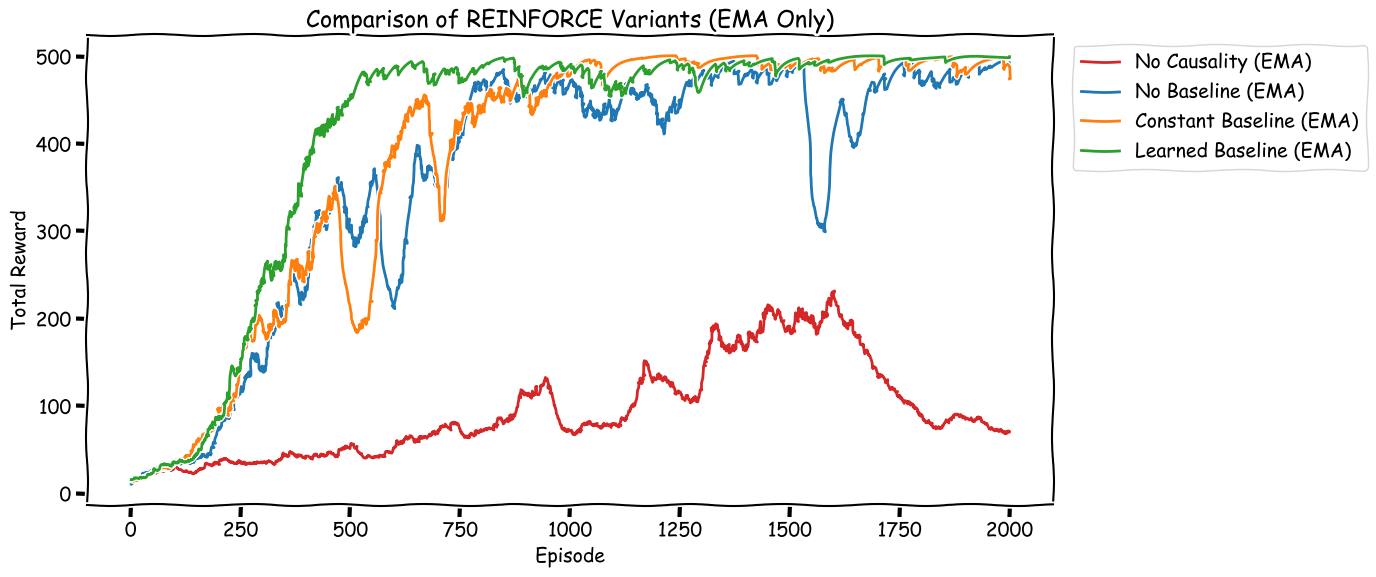

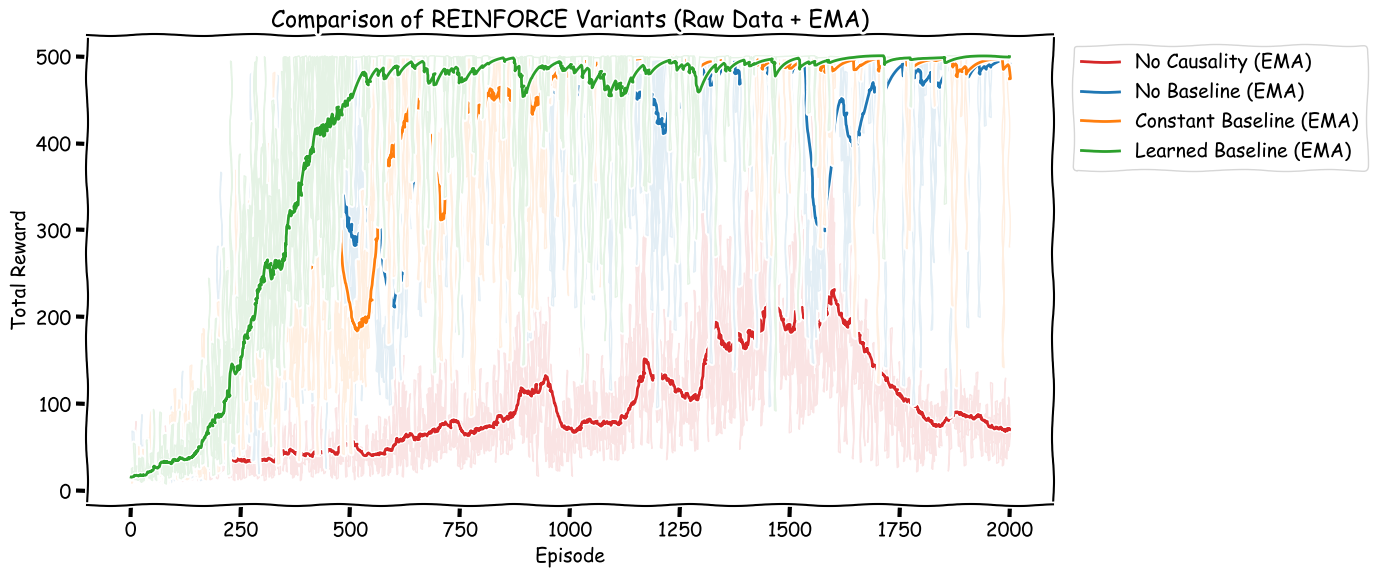

In [26]:
# TODO: Plotting Results
window_size = 50

def exponential_moving_average(data, window_size):
    data = np.asarray(data, dtype=np.float32)

    if len(data) == 0:
        return data

    alpha = 2 / (window_size + 1)
    ema = np.zeros_like(data)
    ema[0] = data[0]

    for i in range(1, len(data)):
        ema[i] = alpha * data[i] + (1 - alpha) * ema[i - 1]

    return ema


methods = [
    (rewards_no_causality, "No Causality", "tab:red"),
    (rewards_no_baseline, "No Baseline", "tab:blue"),
    (rewards_constant_baseline, "Constant Baseline", "tab:orange"),
    (rewards_with_baseline, "Learned Baseline", "tab:green")
]

# Plot 1: EMA only
plt.figure(figsize=(14, 6))

for rewards, label, color in methods:
    episodes = np.arange(1, len(rewards) + 1)
    ema_rewards = exponential_moving_average(rewards, window_size)

    plt.plot(
        episodes,
        ema_rewards,
        color=color,
        linewidth=2,
        label=f"{label} (EMA)"
    )

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Comparison of REINFORCE Variants (EMA Only)")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

# Plot 2: Raw data + EMA
plt.figure(figsize=(14, 6))

for rewards, label, color in methods:
    episodes = np.arange(1, len(rewards) + 1)
    ema_rewards = exponential_moving_average(rewards, window_size)

    # Raw rewards
    plt.plot(
        episodes,
        rewards,
        color=color,
        alpha=0.12,
        linewidth=1
    )

    # EMA-smoothed rewards
    plt.plot(
        episodes,
        ema_rewards,
        color=color,
        linewidth=2,
        label=f"{label} (EMA)"
    )

plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Comparison of REINFORCE Variants (Raw Data + EMA)")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout()
plt.show()

In [27]:
# Calculate and print statistics for all 4 methods
results_stats = [
    ("No Causality", rewards_no_causality),
    ("No Baseline", rewards_no_baseline),
    ("Constant Baseline", rewards_constant_baseline),
    ("Learned Baseline", rewards_with_baseline)
]

for name, rewards in results_stats:
    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    print(f"{name}: mean_reward = {mean_reward:.1f} +/- {std_reward:.1f}")

No Causality: mean_reward = 94.5 +/- 73.4
No Baseline: mean_reward = 369.7 +/- 167.9
Constant Baseline: mean_reward = 390.5 +/- 166.7
Learned Baseline: mean_reward = 419.9 +/- 153.8


**Question:**

Based on the results, how does REINFORCE with a baseline compare to REINFORCE without a baseline in terms of performance?

**Answer:**

REINFORCE with a baseline performs better than REINFORCE without a baseline. In the results, both baseline methods achieve higher average rewards than the no-baseline method. The baseline helps reduce noisy updates, so learning becomes more stable and the agent reaches high rewards more reliably.


**Question:**

Based on the results, how does REINFORCE with a constant baseline compare to REINFORCE with a learned baseline in terms of performance?

**Answer:**

The learned baseline performs better than the constant baseline. The constant baseline improves performance, but the learned baseline gives the highest mean reward and the smoothest learning curve. This is because the learned baseline estimates the value of each state, while the constant baseline uses only one average value for the whole episode.


**Question:**

Based on the results, how does REINFORCE without causality trick compare to REINFORCE with causality trick in terms of performance?


**Answer:**

REINFORCE without the causality trick performs much worse. It has a much lower average reward and learns more slowly. With the causality trick, the agent uses reward-to-go, so each action is updated using only the rewards that come after it. This makes the updates less noisy and improves learning.


**Question:**

Explain how variance affects policy gradient methods, particularly in the context of estimating gradients from sampled trajectories.

**Answer:**

High variance makes policy gradient methods unstable because each sampled episode can give a very different gradient estimate. This means the policy may sometimes improve, but other times a noisy update can hurt performance. Even if the estimate is correct on average, high variance makes learning slower and less reliable. Methods like reward-to-go and baselines reduce variance, making the gradient updates more stable.


# Simulation


In [28]:
# Record the simulation using the policy trained with reward-to-go / no baseline
record_simulation(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    policy_net_causality,
    "Video_CartPole_no_baseline"
)

In [29]:
# Record the simulation using the policy trained without causality trick
record_simulation(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    policy_net_no_causality,
    "Video_CartPole_no_causality"
)

In [30]:
# Record the simulation using the policy trained with constant baseline
record_simulation(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    policy_net_const_baseline,
    "Video_CartPole_constant_baseline"
)

In [31]:
# Record the simulation using the policy trained with learned baseline
record_simulation(
    gym.make("CartPole-v1", render_mode="rgb_array"),
    policy_net_learned_baseline,
    "Video_CartPole_with_baseline"
)

**Question:**

According to the simulations, how does each algorithm perform on the task after the training?

**Answer:**

According to the simulations, the random policy fails very quickly and cannot balance the pole. REINFORCE without the causality trick performs better than random, but it still fails relatively early. REINFORCE with reward-to-go performs very well and balances the pole for the full episode. REINFORCE with a constant baseline also performs well, but in the recorded simulation it does not last as long as the reward-to-go and learned-baseline methods. REINFORCE with a learned baseline also balances the pole for the full episode. Overall, the simulations show that the causality trick and baselines improve performance, while the no-causality method is the weakest trained method.
